# Import Required Libraries
Import the necessary libraries, including TensorFlow, Keras, Matplotlib, and NumPy.

In [1]:
# Import Required Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import imghdr
import os
import pandas as pd
from PIL import Image

/Users/ansel/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# Load and Preprocess the Dataset
Load the dataset, preprocess the images, and create training and validation datasets.

Found 2642 images belonging to 9 classes.
Found 435 images belonging to 9 classes.


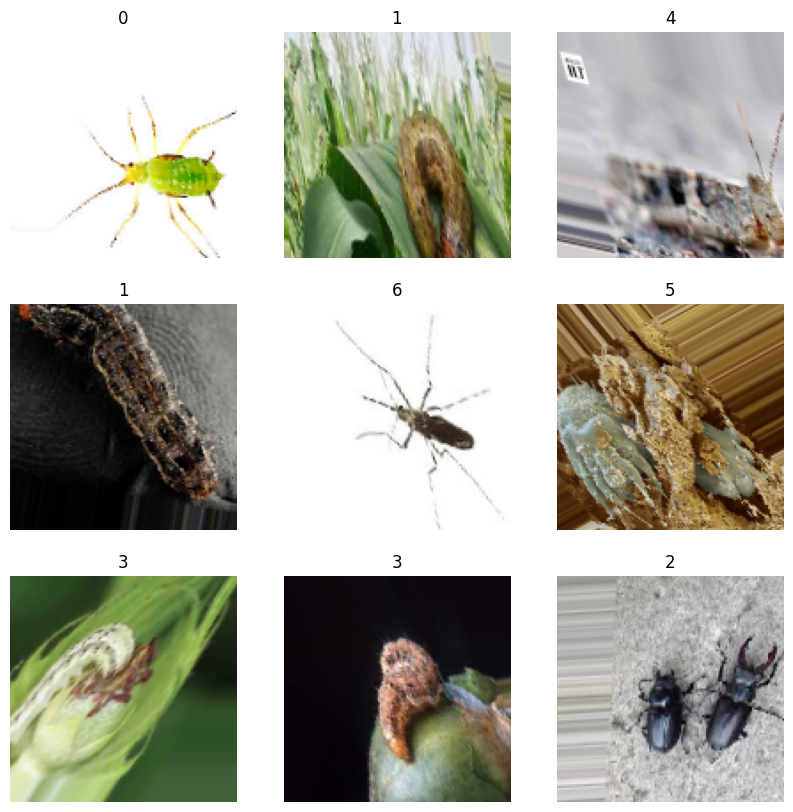

In [2]:
# Load and Preprocess the Dataset

# Define the data directory and image extensions
data_dir = "pest dataset"
image_extensions = [".png", ".jpg"]

# Remove files that are not images
for filepath in Path(data_dir).rglob("*"):
    if filepath.suffix.lower() in image_extensions:
        try:
            img = Image.open(filepath)
            img.verify()
        except IOError:
            print(f"{filepath} is not an image")
            os.remove(filepath)

# Define image size and batch size
image_size = (128, 128)
batch_size = 32

# Data augmentation
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=30,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    rescale=1./255
)

# Load the training dataset
train_ds = datagen.flow_from_directory(
    os.path.join(data_dir, "train"),
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Load the validation dataset
val_ds = datagen.flow_from_directory(
    os.path.join(data_dir, "test"),
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Apply image filtering
def apply_filter(img):
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.adjust_brightness(img, 0.2)
    img = tf.image.adjust_contrast(img, 1.5)
    return img

# Visualize some images from the training dataset
plt.figure(figsize=(10, 10))
for i, (images, labels) in enumerate(train_ds):
    for j in range(9):
        ax = plt.subplot(3, 3, j + 1)
        plt.imshow((images[j] * 255).astype("uint8")) # Multiply by 255 to convert to uint8
        plt.title(int(np.argmax(labels[j])))
        plt.axis("off")
    plt.show()
    break

# Base Model
Define the base model using ResNet50 and add custom layers on top of it.

/Users/ansel/Library/Python/3.9/lib/python/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 173s 2s/step - accuracy: 0.3290 - loss: 2.4235 - val_accuracy: 0.1103 - val_loss: 2.8657
Epoch 2/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.5656 - loss: 1.3088 - val_accuracy: 0.1103 - val_loss: 6.3678
Epoch 3/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 182s 2s/step - accuracy: 0.6450 - loss: 1.0545 - val_accuracy: 0.1149 - val_loss: 5.3611
Epoch 4/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 183s 2s/step - accuracy: 0.7069 - loss: 0.8424 - val_accuracy: 0.1103 - val_loss: 6.9319
Epoch 5/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 178s 2s/step - accuracy: 0.7847 - loss: 0.7008 - val_accuracy: 0.1310 - val_loss: 2.8747
Epoch 6/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 188s 2s/step - accuracy: 0.8245 - loss: 0.5306 - val_accuracy: 0.1103 - val_loss: 7.9339
Epoch 7/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 175s 2s/step - accuracy: 0.8442 - loss: 0.4965 - val_accuracy: 0.1057 - val_loss: 5.5979
Epoch 8/10
83/83 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.8351 - loss: 0.4993 - val_accuracy: 0.1356 - v

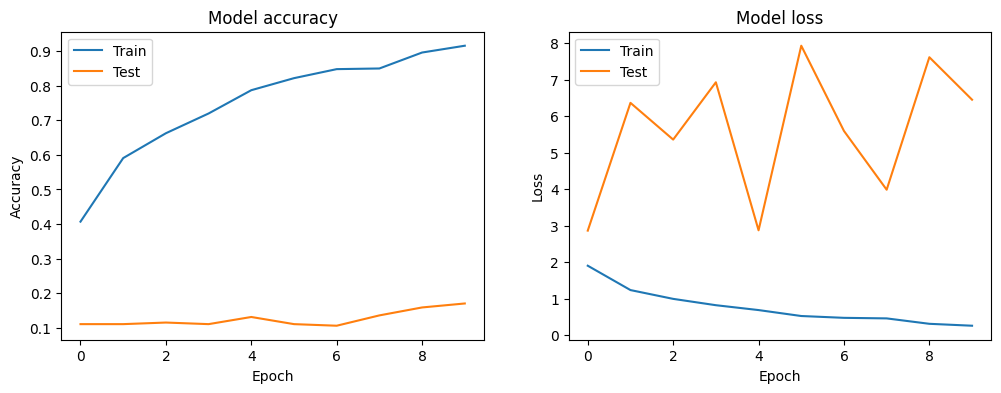

In [3]:
# Base Model

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load the ResNet50 model without the top layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(9, activation='softmax')(x)  # Assuming you have 9 classes

# Create the base model
base_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the base model
base_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the base model and store the history
history_base = base_model.fit(train_ds, validation_data=val_ds, epochs=10)

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_base.history['accuracy'])
plt.plot(history_base.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history_base.history['loss'])
plt.plot(history_base.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.show()

# Test 1
Unfreeze some layers of the base model for fine-tuning.

Epoch 1/35
83/83 ━━━━━━━━━━━━━━━━━━━━ 56s 626ms/step - accuracy: 0.4584 - loss: 1.6197 - val_accuracy: 0.2759 - val_loss: 2.6541
Epoch 2/35
83/83 ━━━━━━━━━━━━━━━━━━━━ 55s 663ms/step - accuracy: 0.5129 - loss: 1.4393 - val_accuracy: 0.4713 - val_loss: 1.6504
Epoch 3/35
83/83 ━━━━━━━━━━━━━━━━━━━━ 58s 695ms/step - accuracy: 0.5597 - loss: 1.2858 - val_accuracy: 0.5310 - val_loss: 1.3111
Epoch 4/35
83/83 ━━━━━━━━━━━━━━━━━━━━ 59s 708ms/step - accuracy: 0.5976 - loss: 1.2527 - val_accuracy: 0.6322 - val_loss: 1.1948
Epoch 5/35
83/83 ━━━━━━━━━━━━━━━━━━━━ 59s 715ms/step - accuracy: 0.6147 - loss: 1.1428 - val_accuracy: 0.6529 - val_loss: 1.0904
Epoch 6/35
83/83 ━━━━━━━━━━━━━━━━━━━━ 60s 723ms/step - accuracy: 0.6328 - loss: 1.0871 - val_accuracy: 0.6644 - val_loss: 1.0699
Epoch 7/35
83/83 ━━━━━━━━━━━━━━━━━━━━ 62s 751ms/step - accuracy: 0.6328 - loss: 1.0946 - val_accuracy: 0.7034 - val_loss: 0.9331
Epoch 8/35
83/83 ━━━━━━━━━━━━━━━━━━━━ 61s 735ms/step - accuracy: 0.6605 - loss: 1.0139 - val_accu

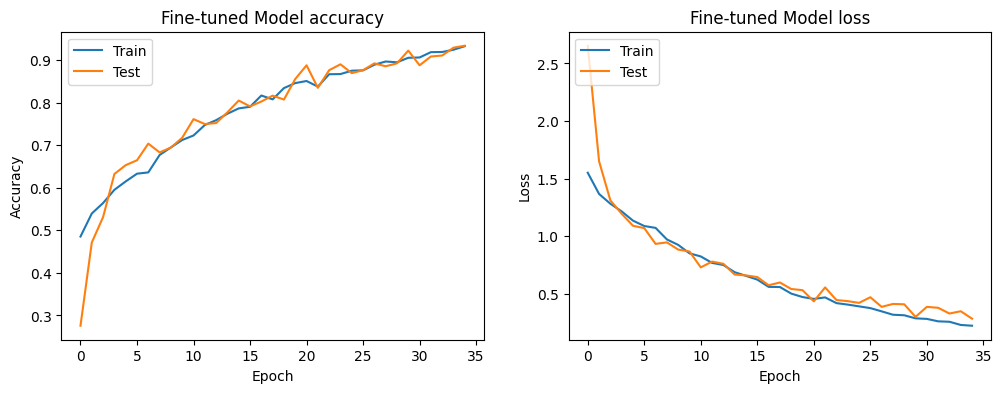

In [4]:
# Test 1

# Unfreeze some layers of the base model
for layer in base_model.layers[:143]:
    layer.trainable = False
for layer in base_model.layers[143:]:
    layer.trainable = True

# Recompile the model with a lower learning rate
base_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Fine-tune the model and store the history
history_fine_tune = base_model.fit(train_ds, validation_data=val_ds, epochs=35)

# Plot training & validation accuracy values for fine-tuning
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history['accuracy'])
plt.plot(history_fine_tune.history['val_accuracy'])
plt.title('Fine-tuned Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values for fine-tuning
plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history['loss'])
plt.plot(history_fine_tune.history['val_loss'])
plt.title('Fine-tuned Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.show()

# Plot Accuracy and Loss
Plot the train and test accuracy and loss for both models using Matplotlib.

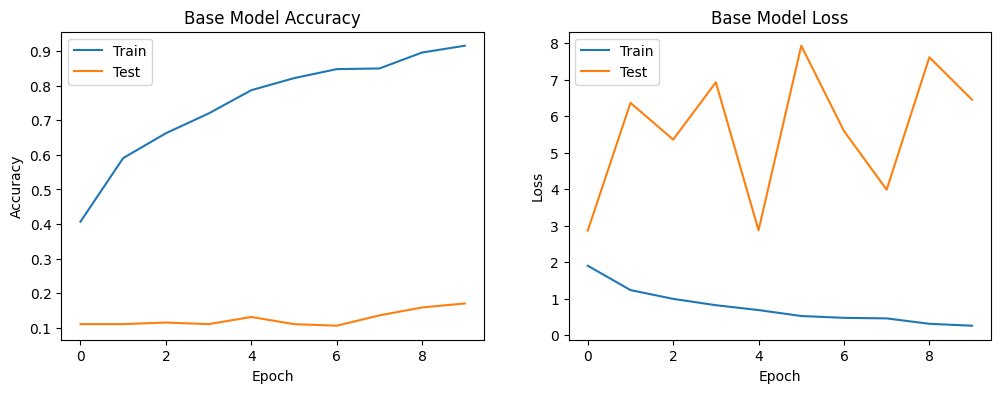

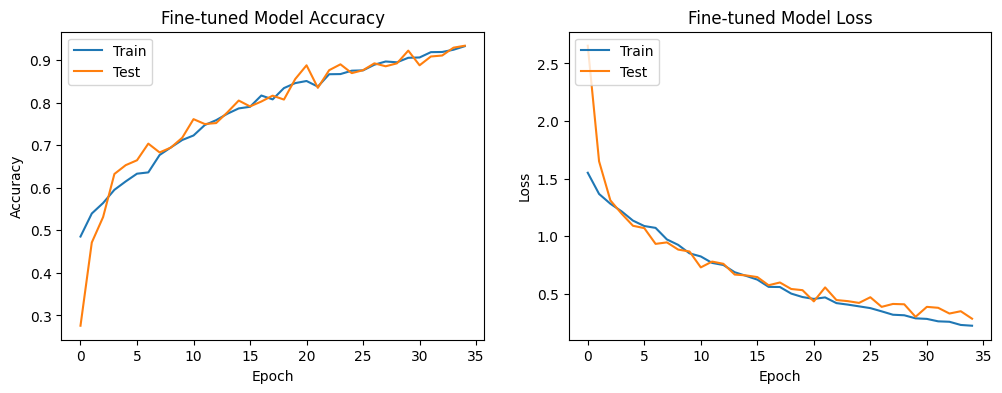

In [5]:
# Plot Accuracy and Loss

# Plot training & validation accuracy values for the base model
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_base.history['accuracy'])
plt.plot(history_base.history['val_accuracy'])
plt.title('Base Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values for the base model
plt.subplot(1, 2, 2)
plt.plot(history_base.history['loss'])
plt.plot(history_base.history['val_loss'])
plt.title('Base Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.show()

# Plot training & validation accuracy values for the fine-tuned model
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_fine_tune.history['accuracy'])
plt.plot(history_fine_tune.history['val_accuracy'])
plt.title('Fine-tuned Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

# Plot training & validation loss values for the fine-tuned model
plt.subplot(1, 2, 2)
plt.plot(history_fine_tune.history['loss'])
plt.plot(history_fine_tune.history['val_loss'])
plt.title('Fine-tuned Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')

plt.show()

# Testing the Fine-tuned Model on images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


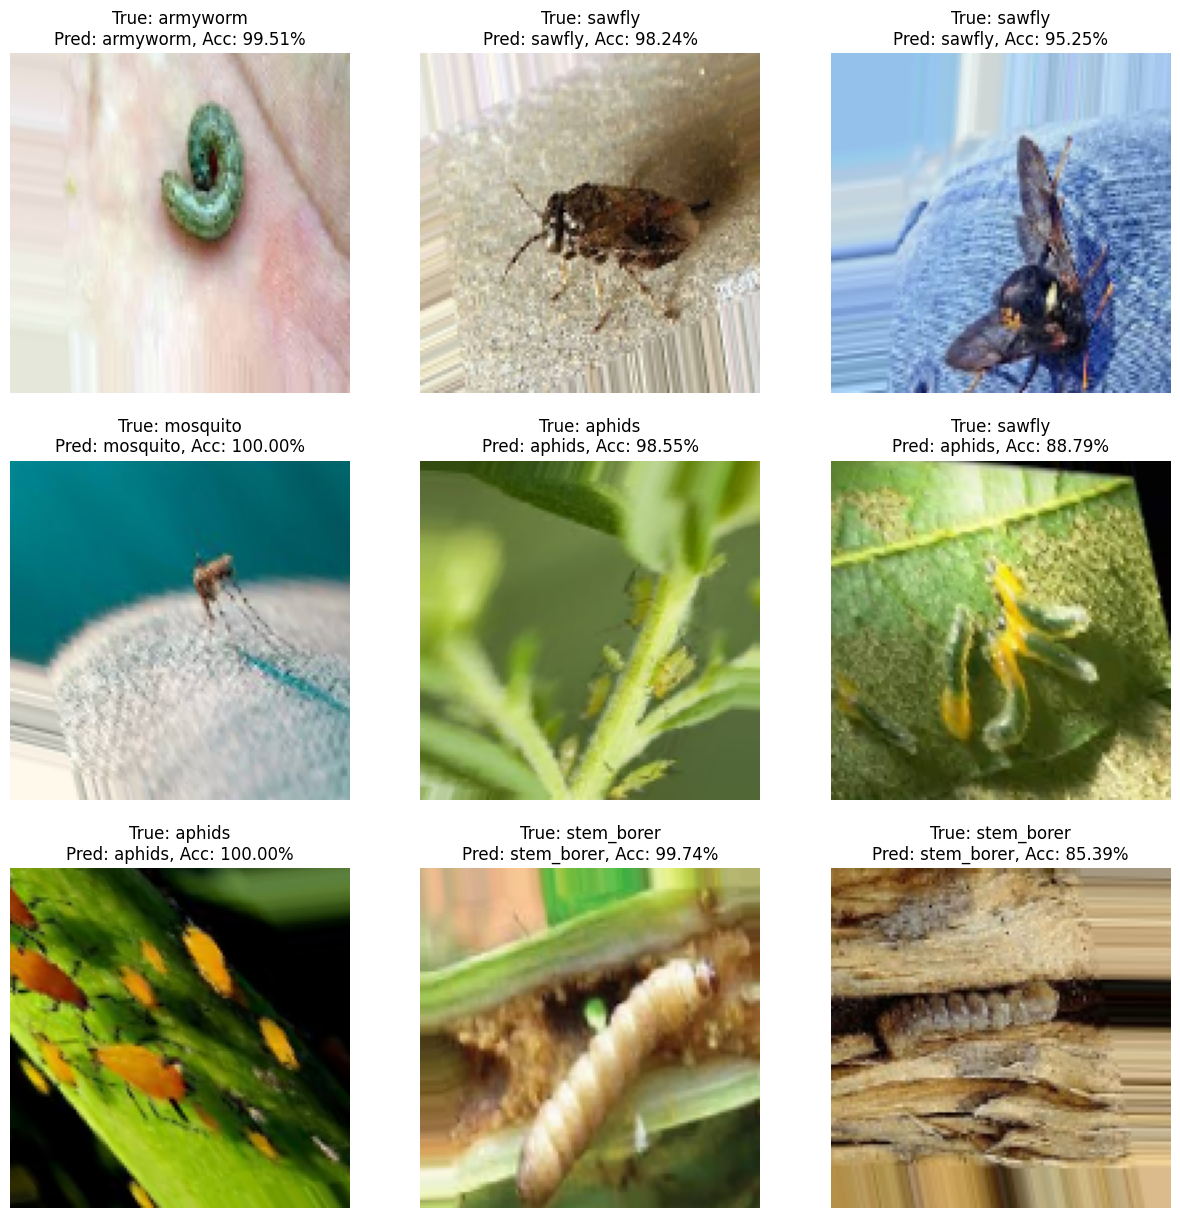

In [6]:
# Get the class names from the training dataset
class_names = list(train_ds.class_indices.keys())

# Load a batch of images from the validation dataset
images, labels = next(iter(val_ds))

# Make predictions using the trained model
predictions = base_model.predict(images)

# Convert predictions and labels to class indices
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(labels, axis=1)

# Calculate accuracy for each prediction
accuracies = np.max(predictions, axis=1) * 100  # Convert to percentage

# Display the images along with the predicted class and accuracy
plt.figure(figsize=(15, 15))
for i in range(9):  # Display 9 images
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow((images[i] * 255).astype("uint8"))  # Multiply by 255 to convert to uint8
    predicted_class_name = class_names[predicted_classes[i]]
    true_class_name = class_names[true_classes[i]]
    plt.title(f"True: {true_class_name}\nPred: {predicted_class_name}, Acc: {accuracies[i]:.2f}%")
    plt.axis("off")
plt.show()

# Testing the model on images that are not in the dataset

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Predicted class: beetle (Confident)


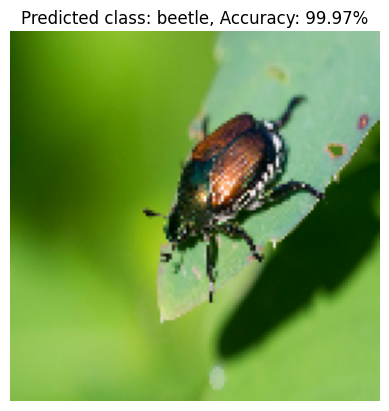

In [40]:
# Load the single image from the new directory
img_path = '/Users/ansel/Documents/vs code/Final Project IS/test images/6.jpg'
img = tf.io.read_file(img_path)
img = tf.image.decode_jpeg(img, channels=3)
img = tf.image.resize(img, (128, 128))  # assuming your model expects 128x128 images

# Preprocess the image to match the model's input format
img = tf.image.convert_image_dtype(img, tf.float32)
img = img / 255.0  # normalize pixel values to [0, 1] range

# Make predictions using the trained model
predictions = base_model.predict(img[None, ...])  # add batch dimension

# Convert prediction to class index
predicted_class = np.argmax(predictions)

# Get the class name from the class index
predicted_class_name = class_names[predicted_class]

# Calculate accuracy
accuracy = np.max(predictions) * 100  # Convert to percentage

# Set a threshold value (e.g. 80%)
threshold = 70

# Check if the accuracy is above the threshold
if accuracy >= threshold:
    print(f"Predicted class: {predicted_class_name} (Confident)")
    plt.title(f"Predicted class: {predicted_class_name}, Accuracy: {accuracy:.2f}%")
else:
    print(f"Predicted class: (Unidentified), Data not found in the Dataset")
    plt.title(f"Unidentified, Accuracy: {accuracy:.2f}%")

# Display the image and prediction
plt.imshow((img.numpy() * 255).astype("uint8"))
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Predicted class: (Unidentified), Data not found in the Dataset


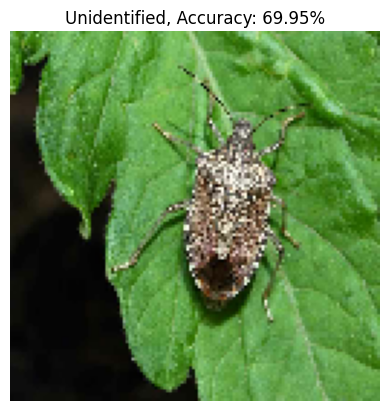

In [41]:
# Load the single image from the new directory
img_path = '/Users/ansel/Documents/vs code/Final Project IS/test images/9.jpg'
img = tf.io.read_file(img_path)
img = tf.image.decode_jpeg(img, channels=3)
img = tf.image.resize(img, (128, 128))  # assuming your model expects 128x128 images

# Preprocess the image to match the model's input format
img = tf.image.convert_image_dtype(img, tf.float32)
img = img / 255.0  # normalize pixel values to [0, 1] range

# Make predictions using the trained model
predictions = base_model.predict(img[None, ...])  # add batch dimension

# Convert prediction to class index
predicted_class = np.argmax(predictions)

# Get the class name from the class index
predicted_class_name = class_names[predicted_class]

# Calculate accuracy
accuracy = np.max(predictions) * 100  # Convert to percentage

# Set a threshold value (e.g. 80%)
threshold = 70

# Check if the accuracy is above the threshold
if accuracy >= threshold:
    print(f"Predicted class: {predicted_class_name} (Confident)")
    plt.title(f"Predicted class: {predicted_class_name}, Accuracy: {accuracy:.2f}%")
else:
    print(f"Predicted class: (Unidentified), Data not found in the Dataset")
    plt.title(f"Unidentified, Accuracy: {accuracy:.2f}%")

# Display the image and prediction
plt.imshow((img.numpy() * 255).astype("uint8"))
plt.axis("off")
plt.show()